# Bank Customer Churn Prediction

**Business question:** Which bank customers are most likely to leave, and what drives it?

**Data:** 10,000 bank customers from Kaggle (Churn_Modelling.csv); about 20% left the bank.

**Approach:** Explore churn by customer attributes, encode categorical variables, then compare five classification models (logistic regression, SVM, decision tree, random forest, gradient boosting) using 5-fold cross-validated AUC.

**Summary of results:** _Best Model is Gradient Boosting with an AUC of .875. The best predictor variables of churn are Age, Number of Products and Georgrphy.Geography Germany is in there as it is has a much larger churn than France and Spain. The recommendations to lessen churn are targeting German customers, inactive members, and customers aged 45+.

In [1]:
# Importing the required packages
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier as dtc # tree algorithm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Churn_df = pd.read_csv('Churn_Modelling.csv')


**Get info on columns in dataset** 

In [2]:
Churn_df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Find shape of dataset**

In [3]:
Churn_df.shape

(10000, 13)

**Display first 5 rows of dataset**

In [4]:
Churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Display last 5 rows**

In [5]:
Churn_df.tail()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


**Find unique rows in Geography for converting to categorical values later**

In [6]:
Churn_df.Geography.unique()

<ArrowStringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

**encode Gender rows**

In [7]:
Churn_df["Gender"] = Churn_df["Gender"].map({"Female": 0, "Male": 1})

**Count of customers exited and stayed**

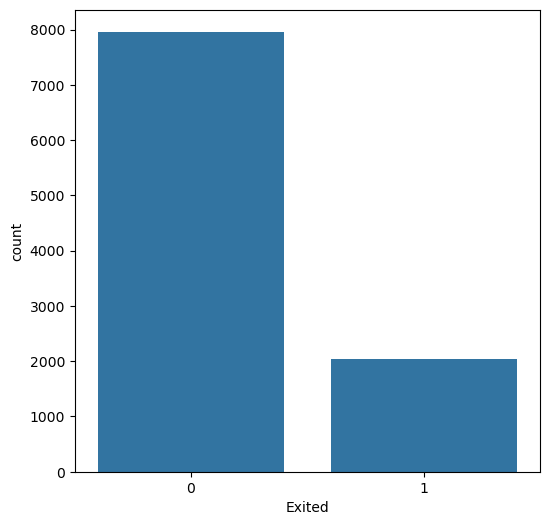

In [8]:
plt.figure(figsize=(6,6))
sns.countplot(x=Churn_df['Exited'])
plt.show()

**Display Column names # of nulls and datatype** 

In [9]:
Churn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  int64  
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(2)
memory usage: 1.1 MB


**Churn by categorical variables (Gender: 0 = Female, 1 = Male)**

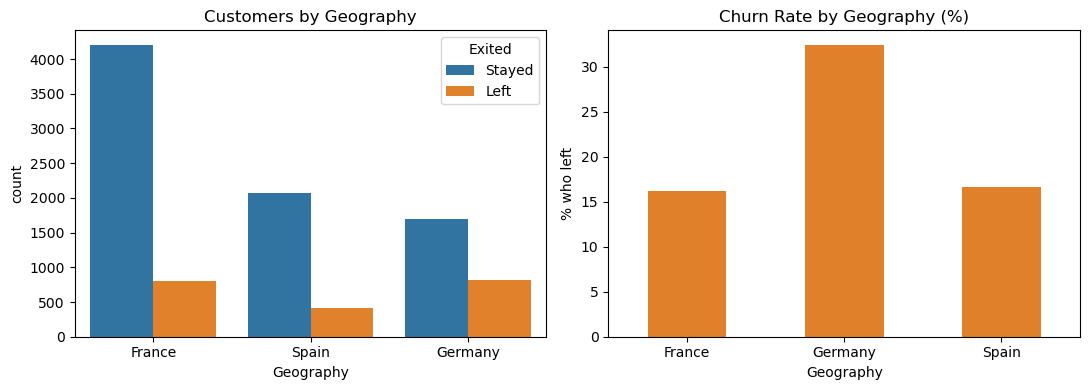

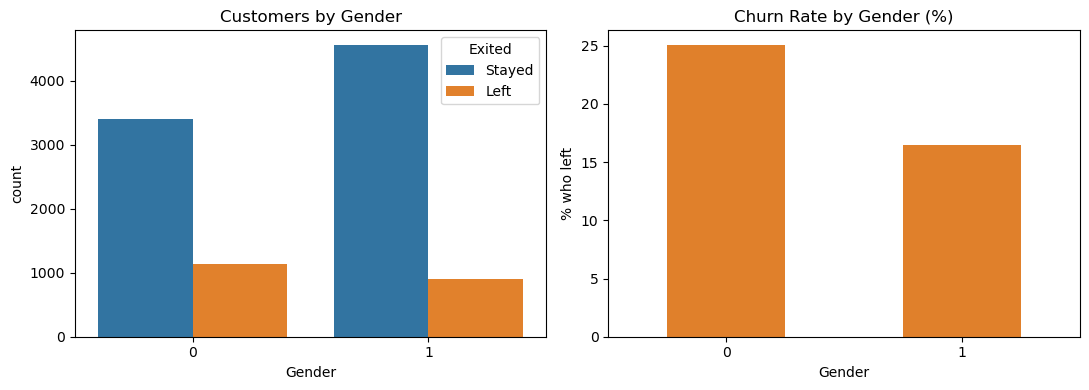

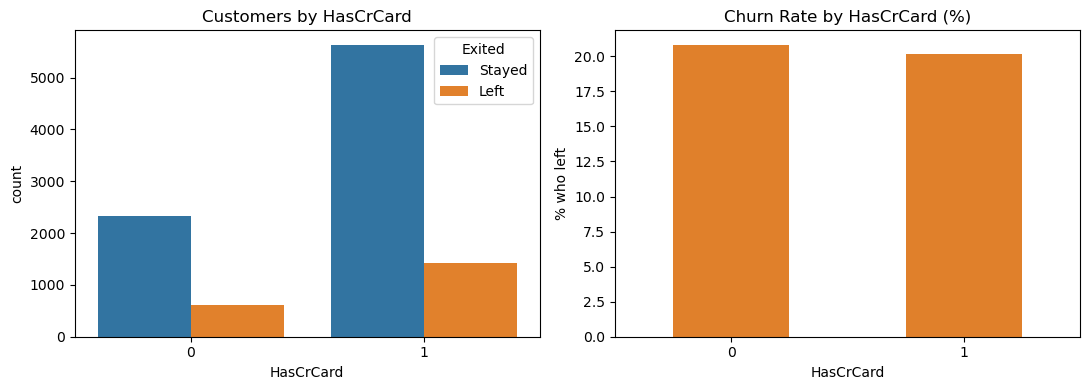

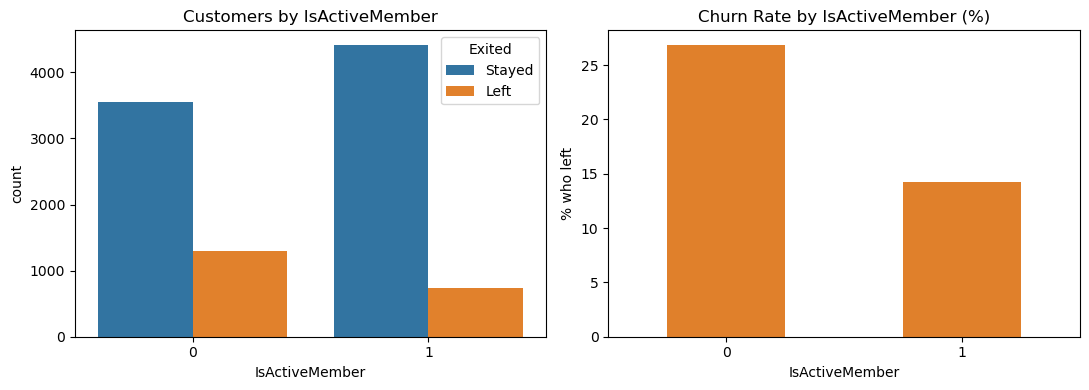

In [10]:
cat_cols = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sns.countplot(data=Churn_df, x=col, hue="Exited", ax=axes[0])
    axes[0].set_title(f"Customers by {col}")
    axes[0].legend(title="Exited", labels=["Stayed", "Left"])

    (Churn_df.groupby(col)["Exited"].mean() * 100).plot(kind="bar", color="#E0802B", ax=axes[1])
    axes[1].set_title(f"Churn Rate by {col} (%)")
    axes[1].set_ylabel("% who left")
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

**Create Box plots of numeric variables in dataset compared to exited**

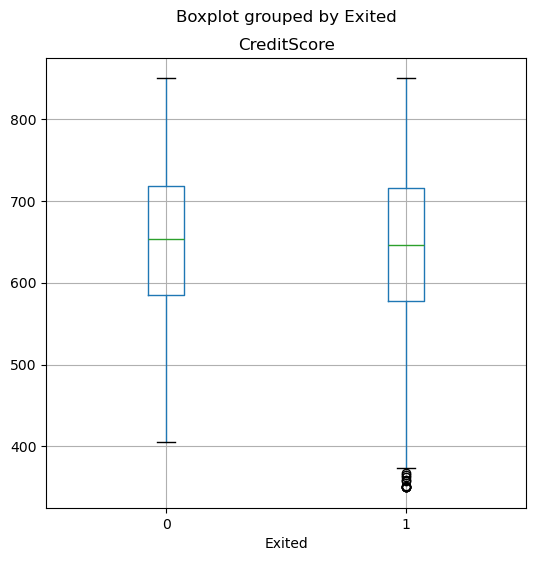

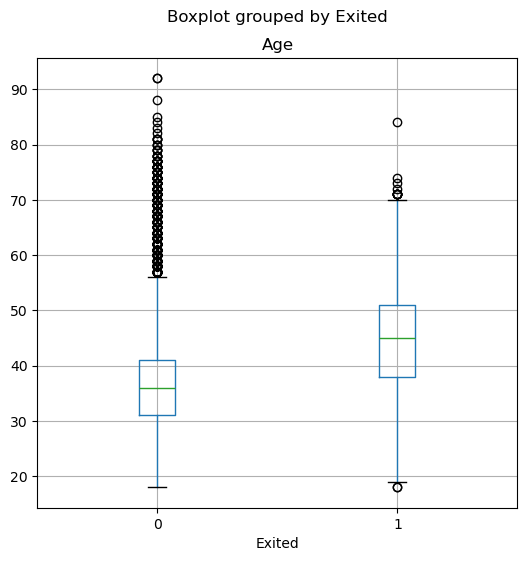

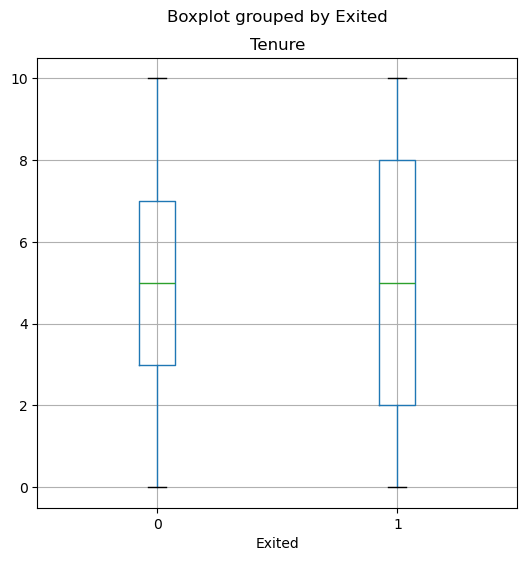

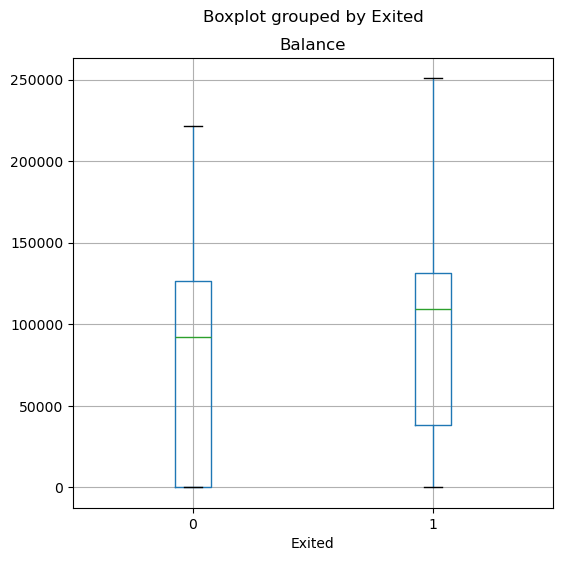

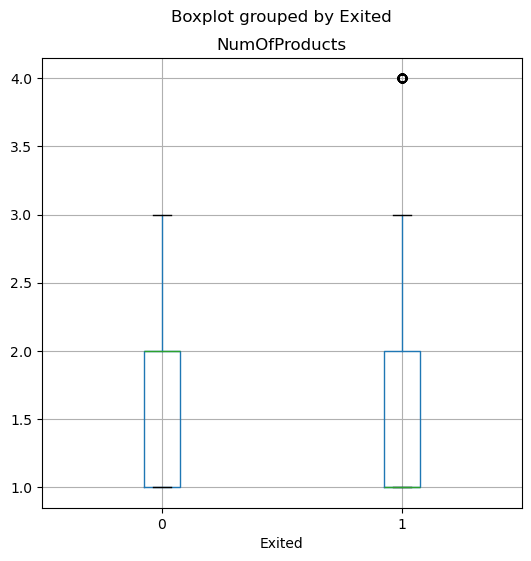

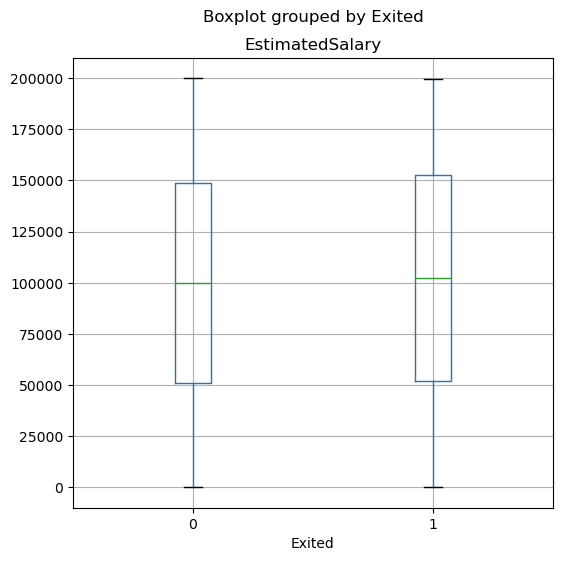

In [11]:
from matplotlib import pyplot as plt
%matplotlib inline

features = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']
for col in features:
    Churn_df.boxplot(column=col, by='Exited', figsize=(6,6))
    plt.title(col)
plt.show()

**Drop Surname and CustomerId, which are identifiers and don't predict churn**

In [12]:
Churn_df = Churn_df.drop(columns=['Surname', 'CustomerId'], errors='ignore')
Churn_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


**Correlation values**

In [13]:

corrM = Churn_df.corr(numeric_only=True)
corrM = corrM.sort_values(by='Exited', ascending=False)
print(corrM)

                 CreditScore    Gender       Age    Tenure   Balance  \
Exited             -0.027094 -0.106512  0.285323 -0.014001  0.118533   
Age                -0.003965 -0.027544  1.000000 -0.009997  0.028308   
Balance             0.006268  0.012087  0.028308 -0.012254  1.000000   
EstimatedSalary    -0.001384 -0.008112 -0.007201  0.007784  0.012797   
HasCrCard          -0.005458  0.005766 -0.011721  0.022583 -0.014858   
Tenure              0.000842  0.014733 -0.009997  1.000000 -0.012254   
CreditScore         1.000000 -0.002857 -0.003965  0.000842  0.006268   
NumOfProducts       0.012238 -0.021859 -0.030680  0.013444 -0.304180   
Gender             -0.002857  1.000000 -0.027544  0.014733  0.012087   
IsActiveMember      0.025651  0.022544  0.085472 -0.028362 -0.010084   

                 NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
Exited               -0.047820  -0.007138       -0.156128         0.012097   
Age                  -0.030680  -0.011721        0.

**Create Correlation heatmap**

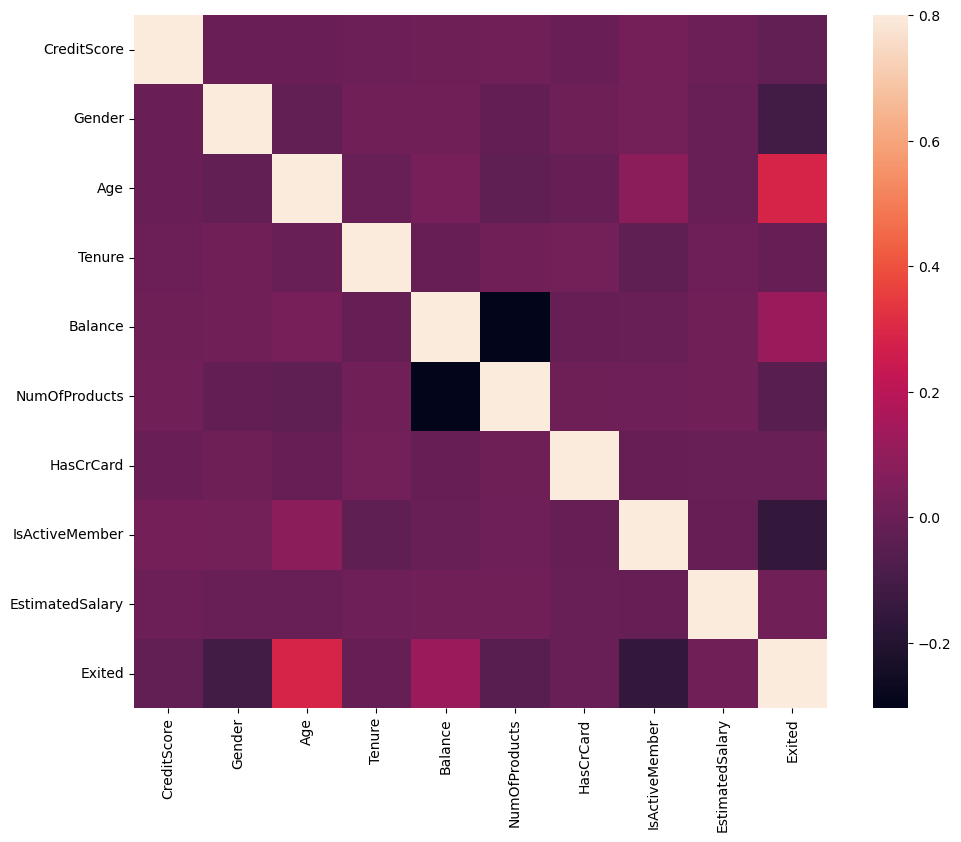

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

corrmat = Churn_df.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);

**Create boxplots of Exited by Age, IsActiveMember, Balance and Credit Score**

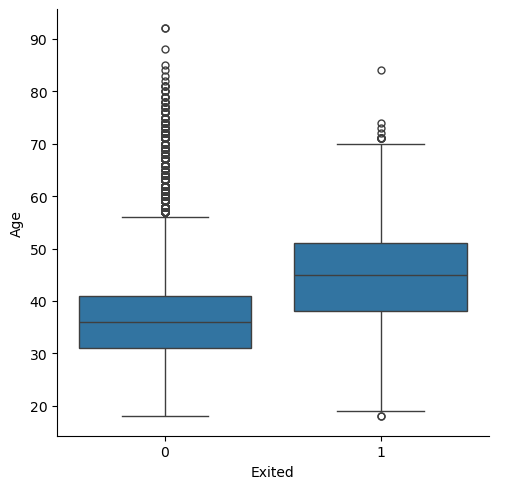

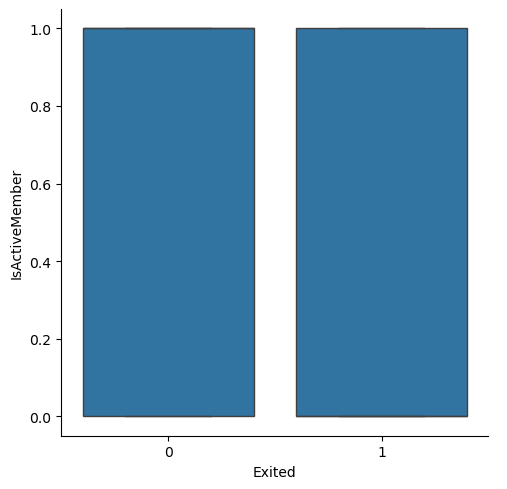

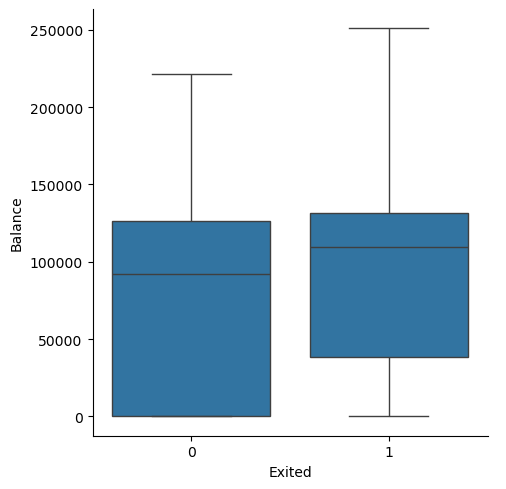

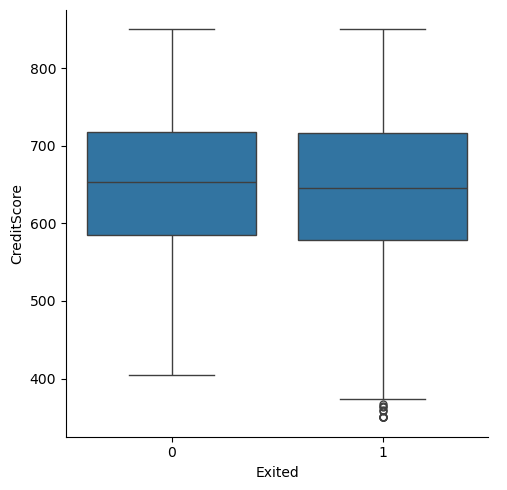

In [15]:
sns.catplot(x="Exited", y="Age",  kind="box",data=Churn_df)
sns.catplot(x="Exited", y="IsActiveMember",  kind="box",data=Churn_df)
sns.catplot(x="Exited", y="Balance",  kind="box",data=Churn_df);
sns.catplot(x="Exited", y="CreditScore",  kind="box",data=Churn_df);

**Show skewness**

In [16]:
print("Skewness: %f" % Churn_df['Balance'].skew())

Skewness: -0.141109


**One-hot encode Geography (France is the baseline)**

In [17]:
if "Geography" in Churn_df.columns:
    Churn_df = pd.get_dummies(Churn_df, columns=["Geography"], drop_first=True, dtype=int)
print(Churn_df.columns.tolist())

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


In [18]:
feature_cols = ['CreditScore', 'Geography_Germany', 'Geography_Spain', 'Gender', 'Age',
                'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                'EstimatedSalary']
target = Churn_df['Exited']
X = Churn_df[feature_cols]
y = target
print(X.columns.tolist())

['CreditScore', 'Geography_Germany', 'Geography_Spain', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

**Model using a decision tree**

In [20]:
from sklearn import tree
model = dtc(criterion = 'entropy', max_depth = 4)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

**Determine Accuracy of model**

In [21]:
accuracy_score(y_test, y_pred)

0.8572

**Text representation of Decision Tree**

In [22]:
text_representation = tree.export_text(model)
print(text_representation)


|--- feature_4 <= 41.50
|   |--- feature_7 <= 2.50
|   |   |--- feature_7 <= 1.50
|   |   |   |--- feature_1 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_1 >  0.50
|   |   |   |   |--- class: 0
|   |   |--- feature_7 >  1.50
|   |   |   |--- feature_6 <= 1884.34
|   |   |   |   |--- class: 0
|   |   |   |--- feature_6 >  1884.34
|   |   |   |   |--- class: 0
|   |--- feature_7 >  2.50
|   |   |--- feature_6 <= 23194.08
|   |   |   |--- feature_10 <= 168592.80
|   |   |   |   |--- class: 0
|   |   |   |--- feature_10 >  168592.80
|   |   |   |   |--- class: 1
|   |   |--- feature_6 >  23194.08
|   |   |   |--- feature_1 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- feature_1 >  0.50
|   |   |   |   |--- class: 1
|--- feature_4 >  41.50
|   |--- feature_7 <= 2.50
|   |   |--- feature_7 <= 1.50
|   |   |   |--- feature_9 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- feature_9 >  0.50
|   |   |   |   |--- class: 0
|   |   |--- feature_7 >  1.50
|   |   |

**Create Confusion Matrix**

In [23]:
pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
True,,,
0,1907,84,1991
1,273,236,509
All,2180,320,2500


**Metrics Classification of model**

In [24]:
import sklearn.metrics as metrics
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1991
           1       0.74      0.46      0.57       509

    accuracy                           0.86      2500
   macro avg       0.81      0.71      0.74      2500
weighted avg       0.85      0.86      0.84      2500



**Run Random Forest to see if it is more accurate than Decision tree** 

In [25]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=170)
clf.fit(X_train,y_train);

**Random forest test-set accuracy**

In [26]:
y_pred=clf.predict(X_test)
Accuracy = metrics.accuracy_score(y_test, y_pred)
print('Accuracy: %.2f' % (Accuracy*100))


Accuracy: 86.96


**Run Classification report for Random Forest**

In [27]:
import sklearn.metrics as metrics
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1991
           1       0.76      0.53      0.62       509

    accuracy                           0.87      2500
   macro avg       0.82      0.74      0.77      2500
weighted avg       0.86      0.87      0.86      2500



**Compare all five models using 5-fold cross-validated AUC on the training set**

In [28]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=50)),
    "SVM": make_pipeline(StandardScaler(), SVC(probability=True)),
    "Decision Tree": DecisionTreeClassifier(criterion="entropy", max_depth=4),
    "Random Forest": RandomForestClassifier(n_estimators=170, random_state=0),
    "Gradient Boosting": GradientBoostingClassifier(random_state=7),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
results = {name: cross_val_score(m, X_train, y_train, cv=cv, scoring="roc_auc").mean()
           for name, m in models.items()}
pd.Series(results).sort_values(ascending=False).round(3)

Gradient Boosting      0.861
Random Forest          0.848
SVM                    0.828
Decision Tree          0.818
Logistic Regression    0.762
dtype: float64

**Final model: gradient boosting, the best cross-validated model, evaluated on the held-out test set**

Gradient Boosting test AUC: 0.875
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1991
           1       0.75      0.52      0.61       509

    accuracy                           0.87      2500
   macro avg       0.82      0.74      0.77      2500
weighted avg       0.86      0.87      0.86      2500



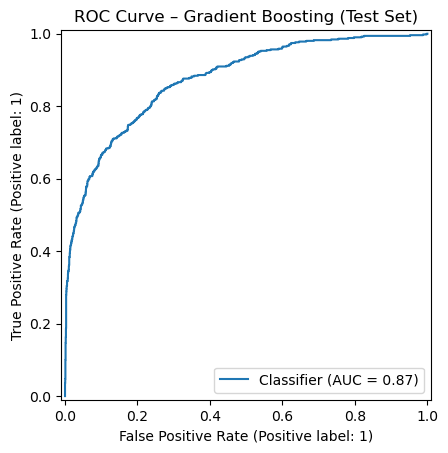

In [29]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay, classification_report

best = GradientBoostingClassifier(random_state=7)
best.fit(X_train, y_train)

probs = best.predict_proba(X_test)[:, 1]
print("Gradient Boosting test AUC:", round(roc_auc_score(y_test, probs), 3))
print(classification_report(y_test, best.predict(X_test)))

RocCurveDisplay.from_predictions(y_test, probs)
plt.title("ROC Curve – Gradient Boosting (Test Set)")
plt.show()

**Top churn drivers**

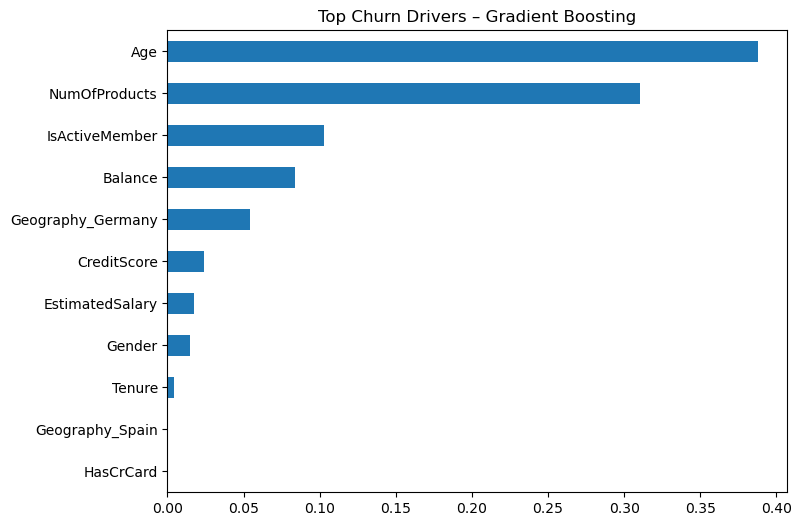

In [30]:
pd.Series(best.feature_importances_, index=feature_cols).sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Top Churn Drivers – Gradient Boosting")
plt.show()